# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Isi Nama Kalian | Isi NRP Kalian|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [101]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [102]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
df = pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [103]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [104]:
df['stalk-root'].value_counts()


stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64

In [105]:
df['stalk-root'] = df['stalk-root'].replace('?', np.nan)
df['stalk-root'].value_counts(dropna=False)

stalk-root
b      3776
NaN    2480
e      1120
c       556
r       192
Name: count, dtype: int64

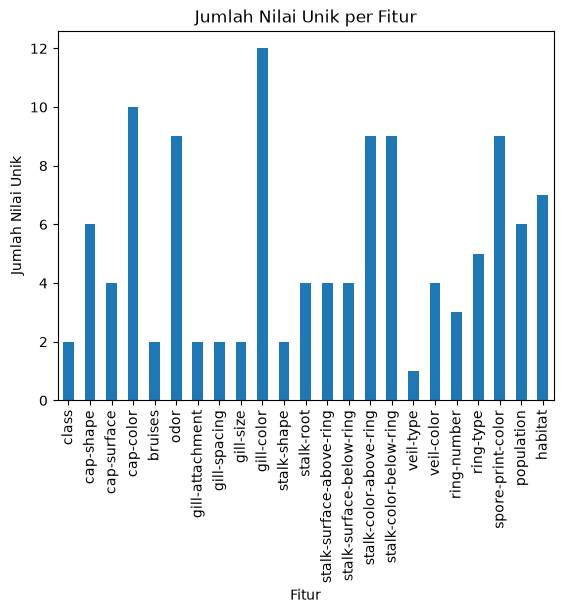

In [106]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
df.nunique().plot(kind='bar', title='Jumlah Nilai Unik per Fitur', xlabel='Fitur', ylabel='Jumlah Nilai Unik')
plt.show()

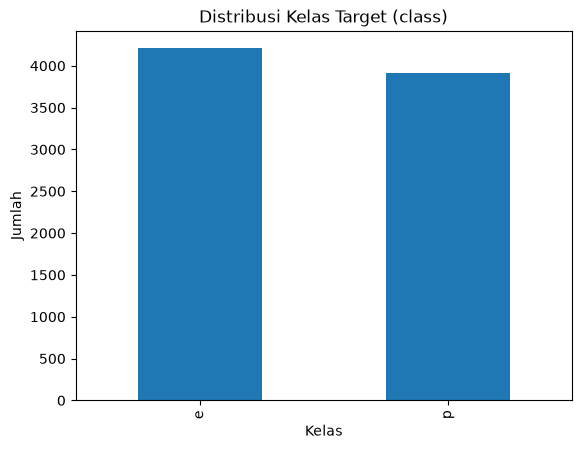

In [107]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
df['class'].value_counts().plot(kind='bar', title='Distribusi Kelas Target (class)', xlabel='Kelas', ylabel='Jumlah')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [108]:
for col in df.columns:
    print(f'\n{col}')
    print(df[col].value_counts())


class
class
e    4208
p    3916
Name: count, dtype: int64

cap-shape
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64

cap-surface
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64

cap-color
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64

bruises
bruises
f    4748
t    3376
Name: count, dtype: int64

odor
odor
n    3528
f    2160
y     576
s     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64

gill-attachment
gill-attachment
f    7914
a     210
Name: count, dtype: int64

gill-spacing
gill-spacing
c    6812
w    1312
Name: count, dtype: int64

gill-size
gill-size
b    5612
n    2512
Name: count, dtype: int64

gill-color
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64

stalk-shape
stalk

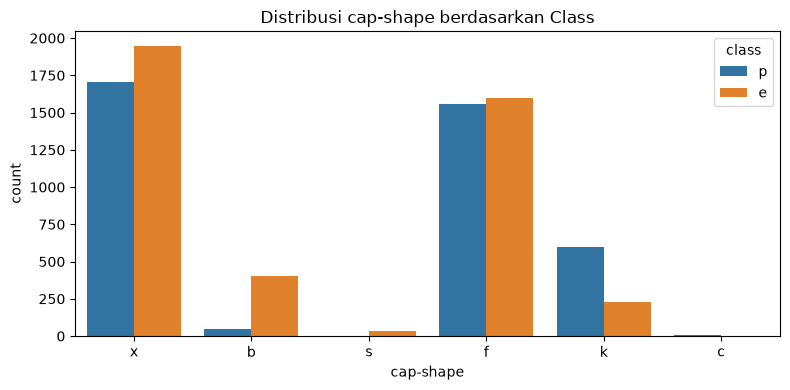

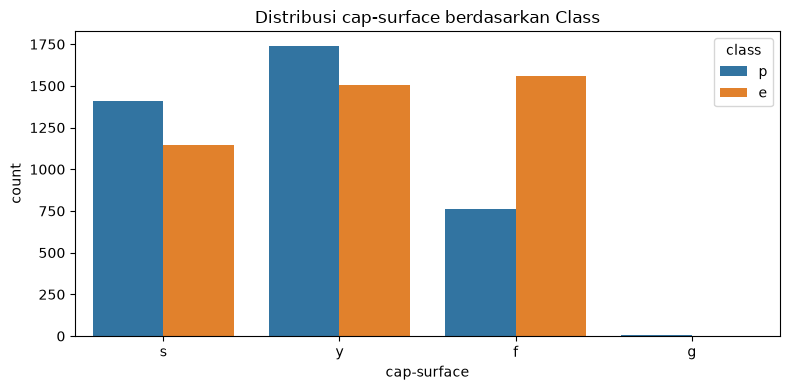

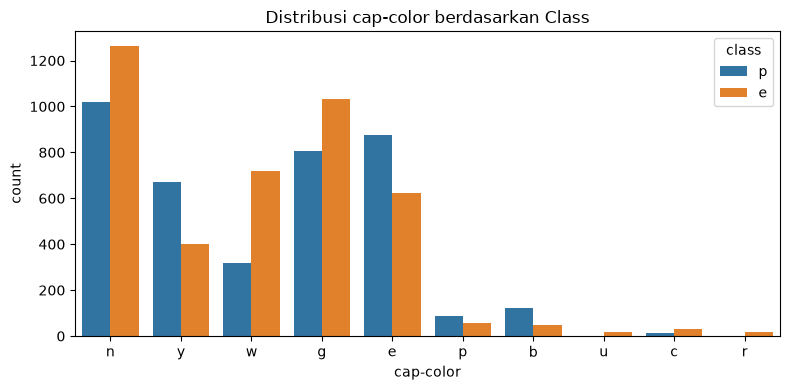

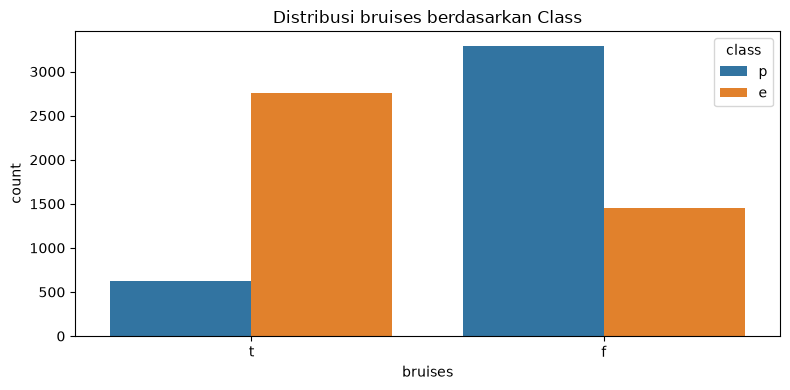

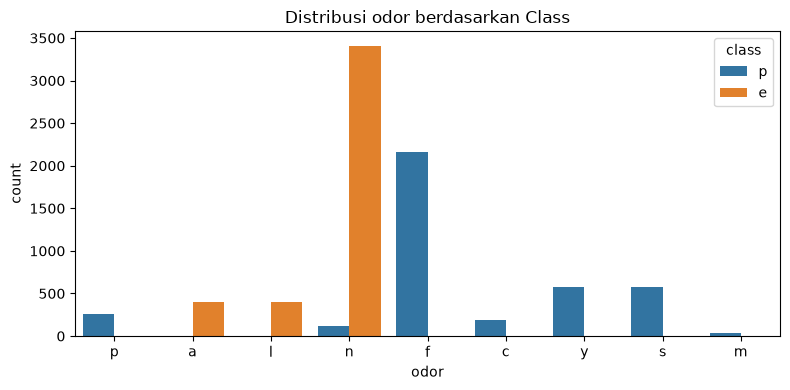

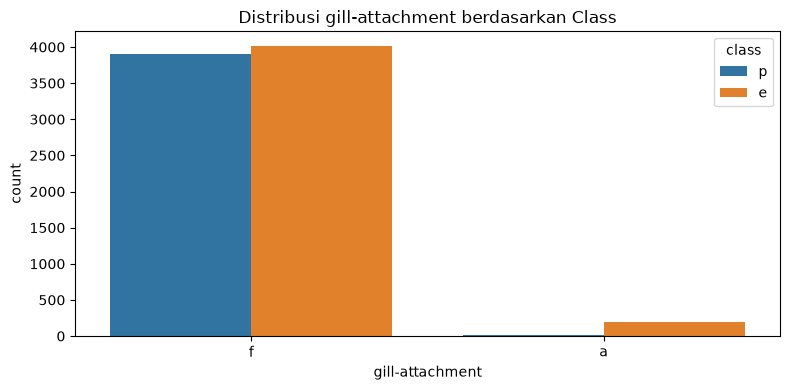

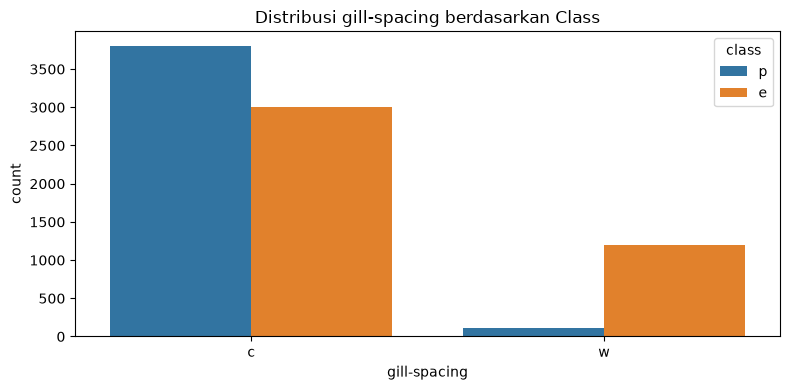

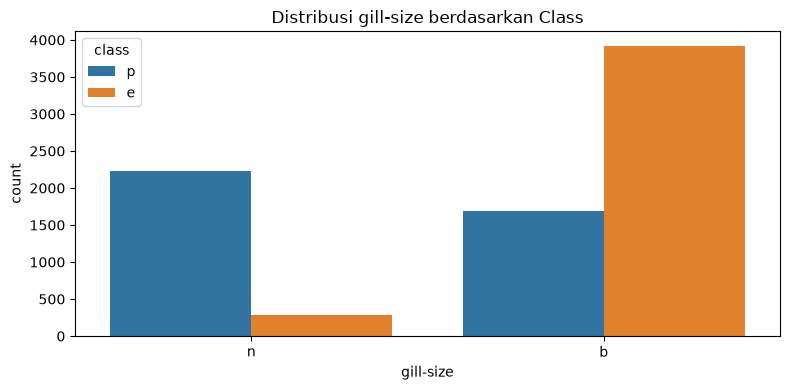

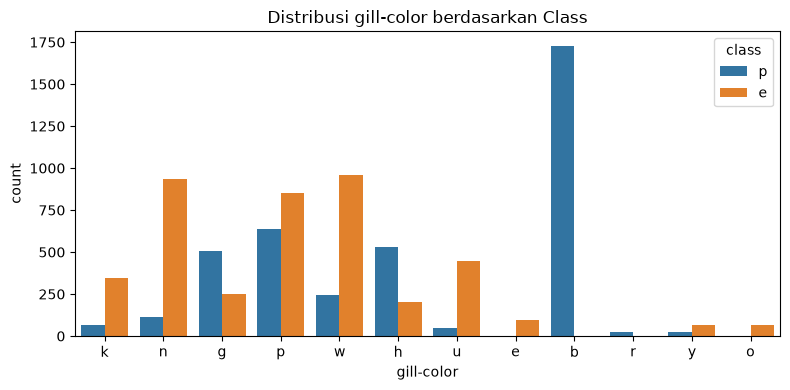

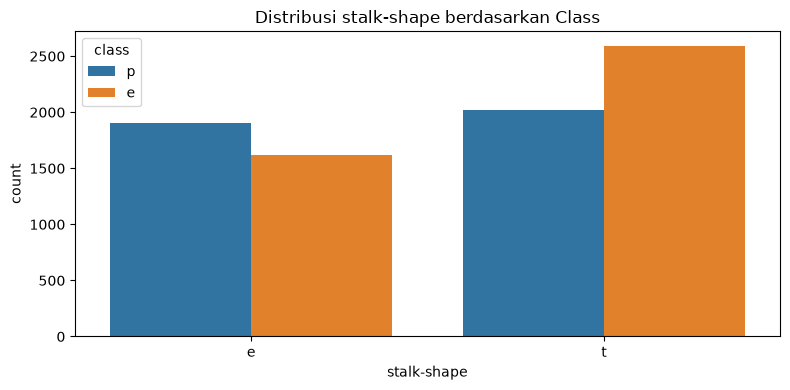

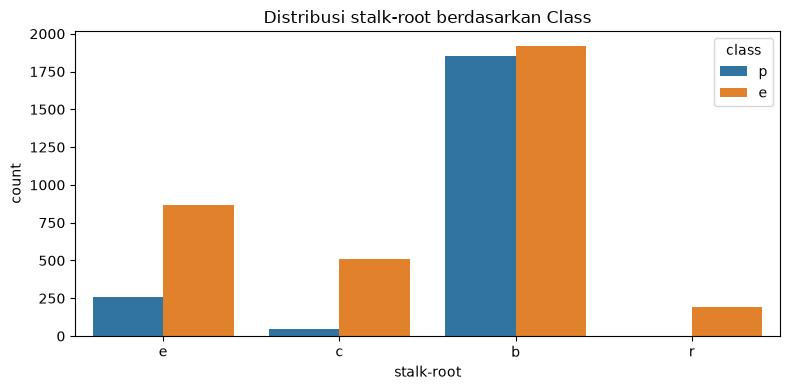

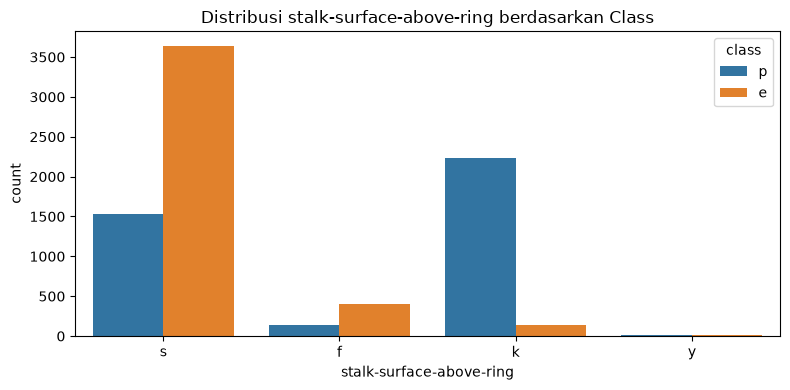

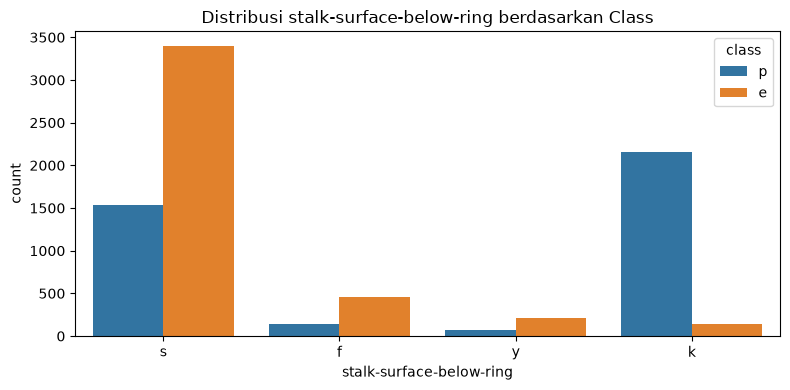

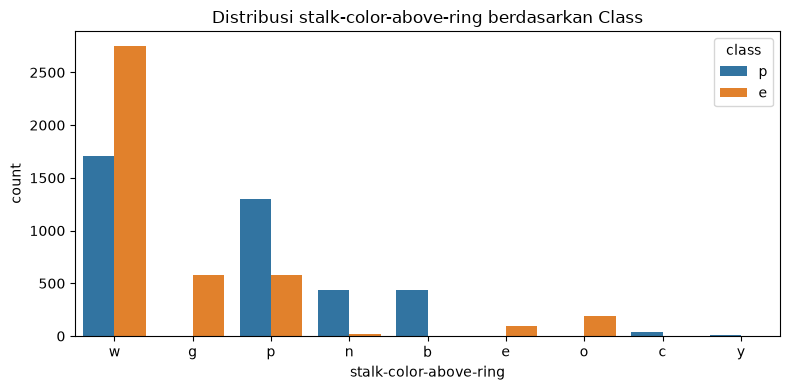

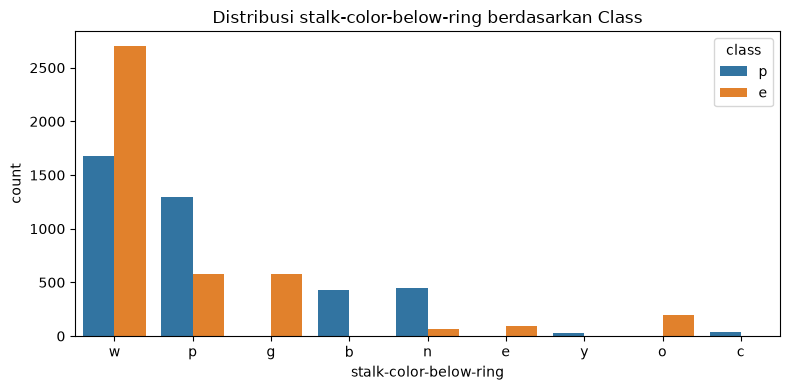

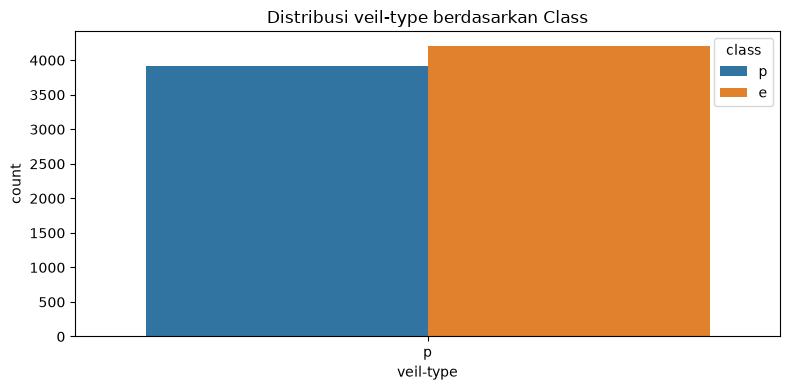

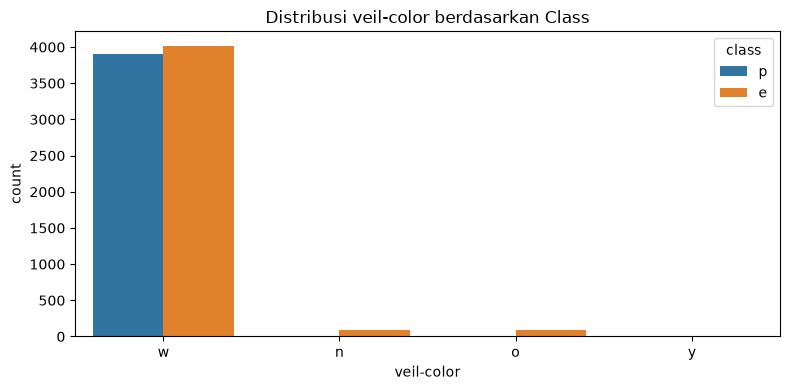

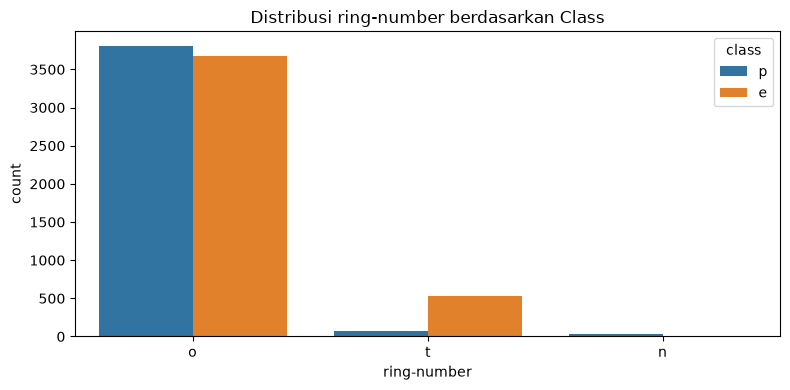

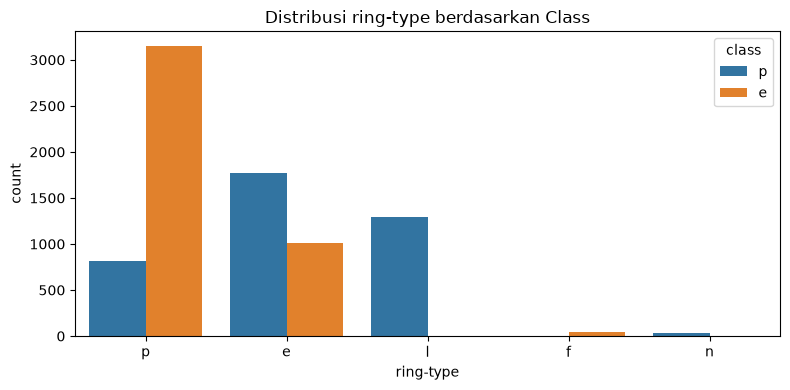

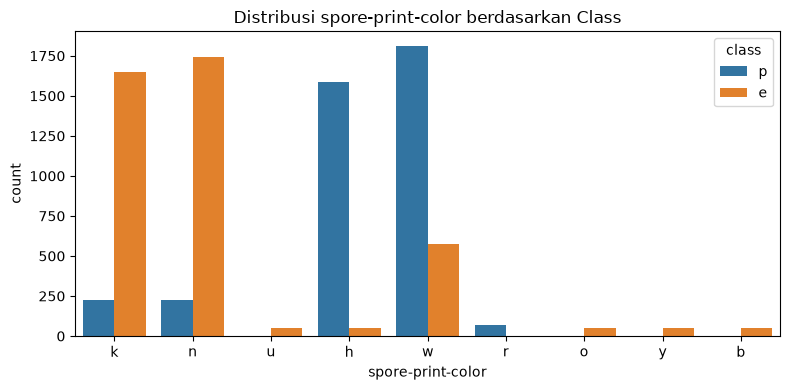

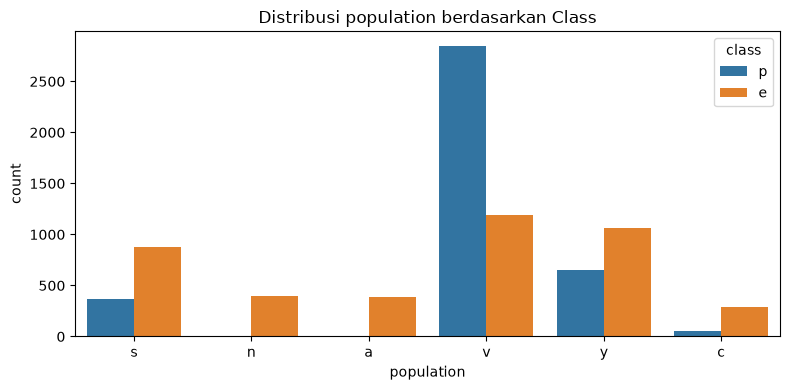

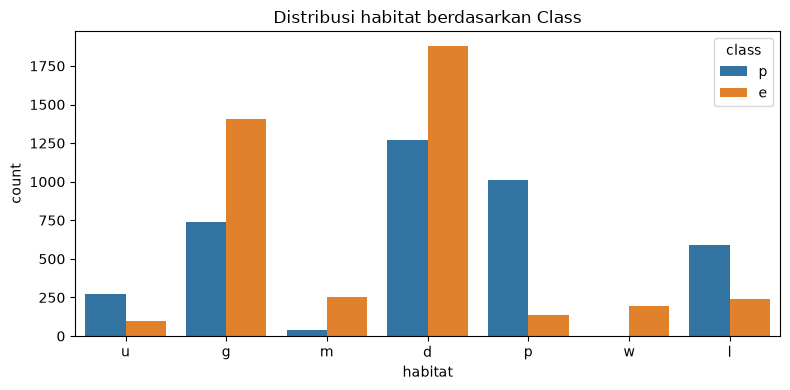

In [109]:
features = df.drop(columns='class').columns

for col in features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='class')
    plt.title(f'Distribusi {col} berdasarkan Class')
    plt.tight_layout()
    plt.show()

In [110]:
for col in features:
    print(f'\n===== {col} =====')
    print(
        pd.crosstab(
            df[col],
            df['class'],
            normalize='index'
        ) * 100
    )


===== cap-shape =====
class               e           p
cap-shape                        
b           89.380531   10.619469
c            0.000000  100.000000
f           50.634518   49.365482
k           27.536232   72.463768
s          100.000000    0.000000
x           53.282276   46.717724

===== cap-surface =====
class                e           p
cap-surface                       
f            67.241379   32.758621
g             0.000000  100.000000
s            44.757433   55.242567
y            46.362515   53.637485

===== cap-color =====
class               e          p
cap-color                       
b           28.571429  71.428571
c           72.727273  27.272727
e           41.600000  58.400000
g           56.086957  43.913043
n           55.341506  44.658494
p           38.888889  61.111111
r          100.000000   0.000000
u          100.000000   0.000000
w           69.230769  30.769231
y           37.313433  62.686567

===== bruises =====
class            e          p


# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [111]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
print(df.nunique()[df.nunique() == 1])
print("Fitur dengan satu nilai unik", df.nunique()[df.nunique() == 1].index.tolist())
df = df.drop(columns=df.nunique()[df.nunique() == 1].index.tolist())

print(df.nunique()[df.nunique() == 1])
print("Fitur dengan satu nilai unik", df.nunique()[df.nunique() == 1].index.tolist())

veil-type    1
dtype: int64
Fitur dengan satu nilai unik ['veil-type']
Series([], dtype: int64)
Fitur dengan satu nilai unik []


In [112]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
df_modus = df.copy()
df_modus['stalk-root'] = df_modus['stalk-root'].fillna(df['stalk-root'].mode()[0])
df_modus['stalk-root'].value_counts(dropna=False)

stalk-root
b    6256
e    1120
c     556
r     192
Name: count, dtype: int64

In [113]:
df_drop = df.copy()
df_drop = df_drop.dropna(subset=['stalk-root'])

In [114]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
x = df.drop(columns=['class'])
y = df['class'].map({'e': 0, 'p': 1})

x_modus = df_modus.drop(columns=['class'])
y_modus = df_modus['class'].map({'e': 0, 'p': 1})

x_drop = df_drop.drop(columns=['class'])
y_drop = df_drop['class'].map({'e': 0, 'p': 1})

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

x_modus_train, x_modus_test, y_modus_train, y_modus_test = train_test_split(
    x_modus,
    y_modus,
    test_size=0.2,
    random_state=42,
    stratify=y_modus
)

x_drop_train, x_drop_test, y_drop_train, y_drop_test = train_test_split(
    x_drop,
    y_drop,
    test_size=0.2,
    random_state=42,
    stratify=y_drop
)


In [115]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
# Gunakan encoder terpisah untuk varian modus dan drop agar fit tidak saling menimpa.
encoder_modus_cat = OrdinalEncoder()
x_modus_train_categorical = encoder_modus_cat.fit_transform(x_modus_train)
x_modus_test_categorical = encoder_modus_cat.transform(x_modus_test)

encoder_drop_cat = OrdinalEncoder()
x_drop_train_categorical = encoder_drop_cat.fit_transform(x_drop_train)
x_drop_test_categorical = encoder_drop_cat.transform(x_drop_test)

In [116]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
# Gunakan encoder terpisah untuk varian modus dan drop agar fit tidak saling menimpa.
encoder_modus_onehot = OneHotEncoder(handle_unknown='ignore')
x_modus_train_onehot = encoder_modus_onehot.fit_transform(x_modus_train)
x_modus_test_onehot = encoder_modus_onehot.transform(x_modus_test)

encoder_drop_onehot = OneHotEncoder(handle_unknown='ignore')
x_drop_train_onehot = encoder_drop_onehot.fit_transform(x_drop_train)
x_drop_test_onehot = encoder_drop_onehot.transform(x_drop_test)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [117]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
# Dilatih dua kali: varian modus dan varian drop (missing stalk-root di-drop).
categorical_nb = CategoricalNB()
categorical_nb.fit(x_modus_train_categorical, y_modus_train)

categorical_nb_drop = CategoricalNB()
categorical_nb_drop.fit(x_drop_train_categorical, y_drop_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 210.... 0., 909.]]), array([[1123....444., 676.]]), array([[ 0.,... 242., 526.]]), array([[ 737....224., 501.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[2790.,1725.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.48,-0.96]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.58...-0.64300996]]), array([[-0.91...-0.93762721]]), array([[-7.93...-1.19040874]]), array([[-1.33...-1.23554096]]), ...]"


In [118]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
# Dibuat untuk varian modus dan drop.
y_cat_pred = categorical_nb.predict(x_modus_test_categorical)
y_cat_prob = categorical_nb.predict_proba(x_modus_test_categorical)[:, 1]

y_cat_pred_drop = categorical_nb_drop.predict(x_drop_test_categorical)
y_cat_prob_drop = categorical_nb_drop.predict_proba(x_drop_test_categorical)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [ ]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(x_modus_train_onehot, y_modus_train)

bernoulli_nb_drop = BernoulliNB()
bernoulli_nb_drop.fit(x_drop_train_onehot, y_drop_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[2790.,1725.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.48,-0.96]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 97)","[[ 210., 0.,1174.,..., 200., 109., 79.], [ 33., 3., 770.,..., 31., 352., 225.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 97)","[[-2.58,-7.93,-0.87,...,-2.63,-3.23,-3.55], [-3.93,-6.07,-0.81,...,-3.99,-1.59,-2.03]]"


In [ ]:
y_bern_pred = bernoulli_nb.predict(x_modus_test_onehot)
y_bern_prob = bernoulli_nb.predict_proba(x_modus_test_onehot)[:, 1]

y_bern_pred_drop = bernoulli_nb_drop.predict(x_drop_test_onehot)
y_bern_prob_drop = bernoulli_nb_drop.predict_proba(x_drop_test_onehot)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [ ]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
multinomial_nb = MultinomialNB()
multinomial_nb.fit(x_modus_train_onehot, y_modus_train)

multinomial_nb_drop = MultinomialNB()
multinomial_nb_drop.fit(x_drop_train_onehot, y_drop_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[2790.,1725.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.48,-0.96]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 97)","[[ 210., 0.,1174.,..., 200., 109., 79.], [ 33., 3., 770.,..., 31., 352., 225.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 97)","[[ -5.63,-10.98, -3.91,..., -5.68, -6.28, -6.6 ], [ -6.97, -9.11, -3.85,..., -7.03, -4.63, -5.08]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,97


In [ ]:
# Lakukan prediksi pada test set.
y_multi_pred = multinomial_nb.predict(x_modus_test_onehot)
y_multi_prob = multinomial_nb.predict_proba(x_modus_test_onehot)[:, 1]

y_multi_pred_drop = multinomial_nb_drop.predict(x_drop_test_onehot)
y_multi_prob_drop = multinomial_nb_drop.predict_proba(x_drop_test_onehot)[:, 1]

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
def _scores(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

rows = [
    ['CategoricalNB', 'modus'] + _scores(y_modus_test, y_cat_pred),
    ['CategoricalNB', 'drop'] + _scores(y_drop_test, y_cat_pred_drop),
    ['BernoulliNB', 'modus'] + _scores(y_modus_test, y_bern_pred),
    ['BernoulliNB', 'drop'] + _scores(y_drop_test, y_bern_pred_drop),
    ['MultinomialNB', 'modus'] + _scores(y_modus_test, y_multi_pred),
    ['MultinomialNB', 'drop'] + _scores(y_drop_test, y_multi_pred_drop),
]
results = pd.DataFrame(
    rows, columns=['Model', 'Imputasi', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
).set_index(['Model', 'Imputasi'])
results

Accuracy  Precision    Recall  F1-Score
Model         Imputasi                                         
CategoricalNB modus     0.947077   0.988780  0.900383  0.942513
              drop      0.970771   0.995025  0.928074  0.960384
BernoulliNB   modus     0.933538   0.982833  0.877395  0.927126
              drop      0.941541   0.991914  0.853828  0.917706
MultinomialNB modus     0.947077   0.988780  0.900383  0.942513
              drop      0.970771   0.995025  0.928074  0.960384

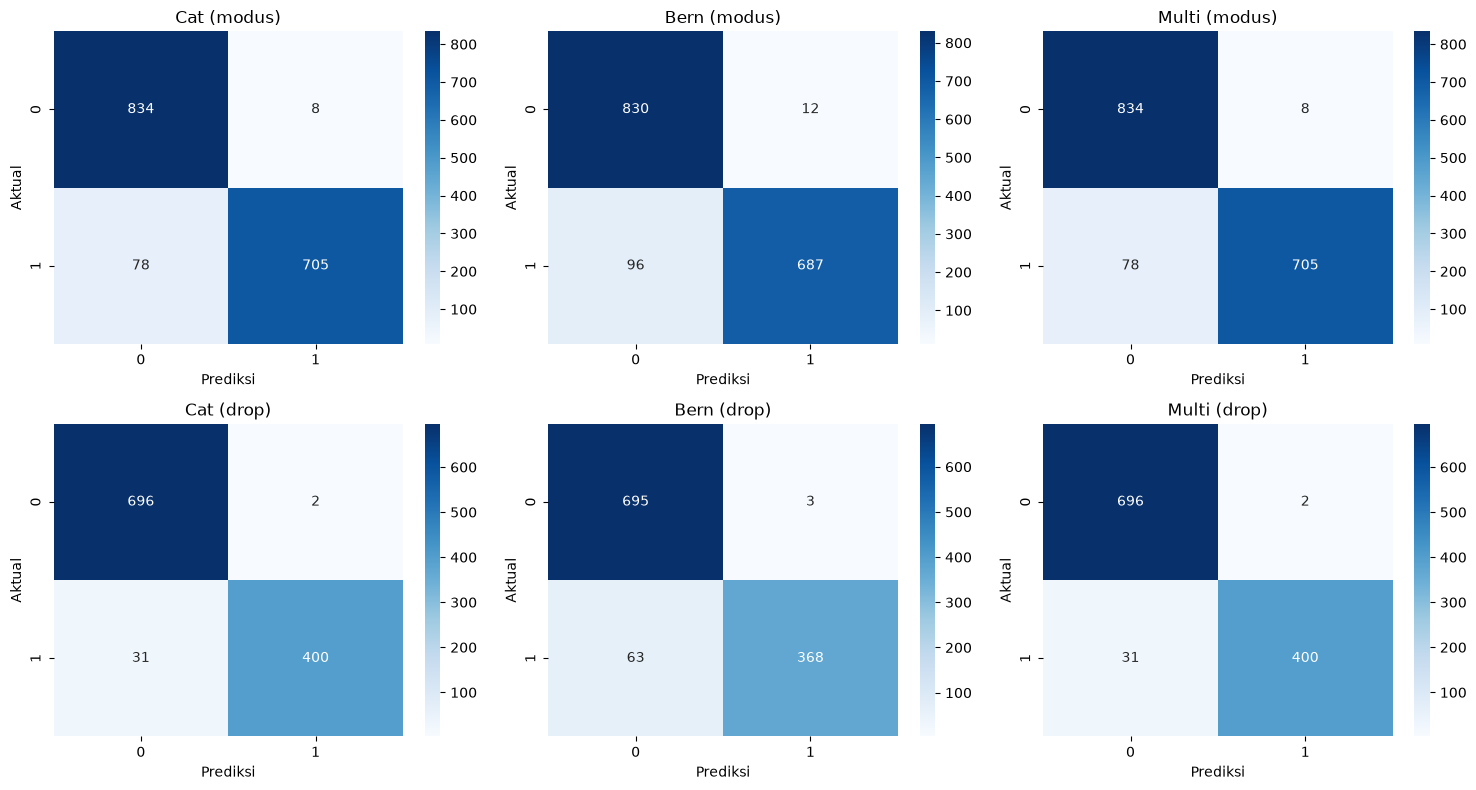

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

pairs = [
    ('Cat (modus)', y_modus_test, y_cat_pred),
    ('Bern (modus)', y_modus_test, y_bern_pred),
    ('Multi (modus)', y_modus_test, y_multi_pred),
    ('Cat (drop)', y_drop_test, y_cat_pred_drop),
    ('Bern (drop)', y_drop_test, y_bern_pred_drop),
    ('Multi (drop)', y_drop_test, y_multi_pred_drop),
]

for ax, (name, y_true, y_pred) in zip(axes.flat, pairs):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

CategoricalNB (modus) AUC: 0.9974
BernoulliNB (modus) AUC: 0.9955
MultinomialNB (modus) AUC: 0.9974
CategoricalNB (drop) AUC: 0.9993
BernoulliNB (drop) AUC: 0.9985
MultinomialNB (drop) AUC: 0.9993


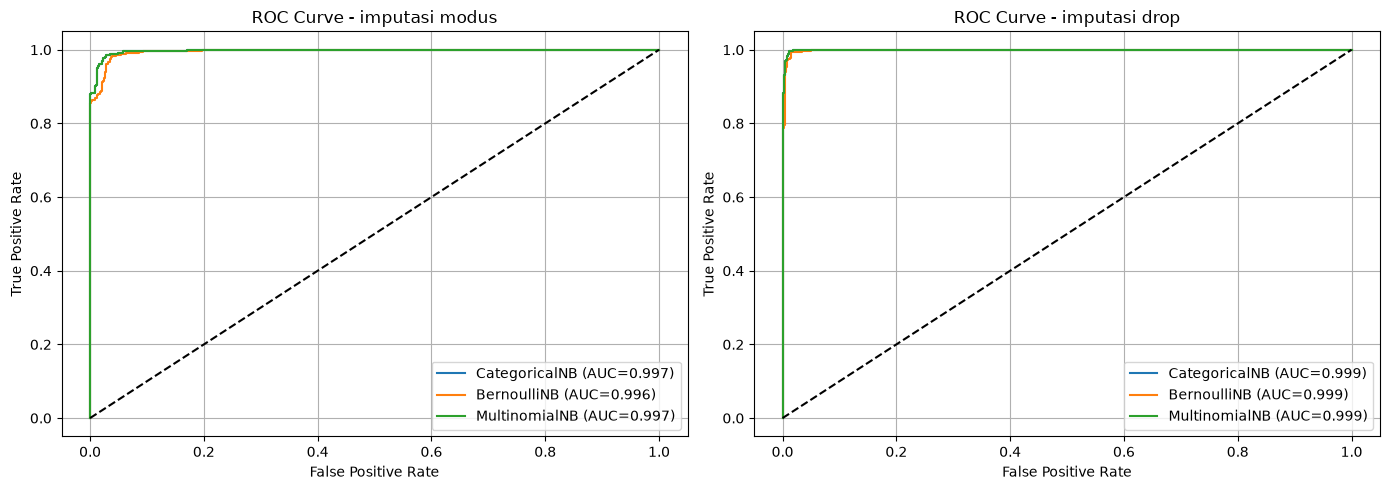

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

roc_groups = [
    (axes[0], 'modus', y_modus_test, [
        ('CategoricalNB', y_cat_prob),
        ('BernoulliNB', y_bern_prob),
        ('MultinomialNB', y_multi_prob),
    ]),
    (axes[1], 'drop', y_drop_test, [
        ('CategoricalNB', y_cat_prob_drop),
        ('BernoulliNB', y_bern_prob_drop),
        ('MultinomialNB', y_multi_prob_drop),
    ]),
]

for ax, tag, y_true, items in roc_groups:
    for name, y_prob in items:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        print(f'{name} ({tag}) AUC: {auc(fpr, tpr):.4f}')
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - imputasi {tag}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# 5. Analisis

## Hasil eksperimen (test set)

| Model | Imputasi | Akurasi | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|---|
| CategoricalNB | modus (n=1625) | 0,947 | 0,989 | 0,900 | 0,943 | 0,997 |
| BernoulliNB | modus (n=1625) | 0,934 | 0,983 | 0,877 | 0,927 | 0,996 |
| MultinomialNB | modus (n=1625) | 0,947 | 0,989 | 0,900 | 0,943 | 0,997 |
| CategoricalNB | drop (n=1129) | 0,971 | 0,995 | 0,928 | 0,960 | 0,999 |
| BernoulliNB | drop (n=1129) | 0,942 | 0,992 | 0,854 | 0,918 | 0,999 |
| MultinomialNB | drop (n=1129) | 0,971 | 0,995 | 0,928 | 0,960 | 0,999 |

### 1. CategoricalNB vs MultinomialNB: skor identik

Pada kedua strategi imputasi, CategoricalNB dan MultinomialNB menghasilkan semua metrik yang sama persis. Ini bukan kebetulan: setiap baris hasil OneHotEncoder selalu berisi tepat 21 nilai 1 (satu per fitur asli), sehingga yang dihitung MultinomialNB sebagai frekuensi praktis proporsional dengan probabilitas kategori per fitur yang dihitung CategoricalNB. Keduanya pada dasarnya memodelkan hal yang sama, hanya representasinya beda (21 kolom integer vs 115/97 kolom biner).

### 2. BernoulliNB paling rendah, terutama recall

BernoulliNB tertinggal di akurasi dan F1 pada kedua imputasi, dan selisih terbesar ada di recall (modus 0,877 vs 0,900; drop 0,854 vs 0,928). Penyebabnya ada di asumsi model: Bernoulli memodelkan ketidakhadiran (nilai 0) secara eksplisit sebagai informasi, padahal pada one-hot hasil encode fitur kategorikal, angka 0 sebagian besar hanya berarti kategori lain yang aktif, bukan tidak adanya sifat. Akibatnya model menghukum kombinasi kategori yang jarang terlihat dan lebih sering gagal mengenali jamur beracun (false negative). Confusion matrix mengonfirmasi hal ini: precision tetap tinggi (~0,98-0,99) tetapi recall turun, artinya saat model memprediksi beracun hampir selalu benar, namun cukup banyak jamur beracun yang lolos diprediksi edible. Dalam konteks nyata hal ini berbahaya karena salah memakan jamur beracun berakibat fatal.

### 3. Modus vs drop: angka drop lebih tinggi tetapi tidak apple-to-apple

Semua model mendapat akurasi lebih tinggi pada varian drop. Namun perbandingan ini harus dibaca hati-hati karena test set-nya berbeda: modus diuji pada 1625 data sedangkan drop hanya 1129 data, dan komposisi kelasnya berubah (modus sekitar 52% edible / 48% poisonous, drop sekitar 62% / 38% karena baris yang dibuang mayoritas mengandung pola tertentu). Imputasi modus mempertahankan seluruh 8124 baris tetapi mengisi 2480 missing stalk-root (30% data) dengan nilai b yang mendominasi, sehingga memasukkan noise dan membuat tugas klasifikasi sedikit lebih sulit. Sebaliknya drop membuang 30% data sehingga model berlatih dan diuji pada subset yang lebih bersih, tetapi dengan risiko membuang pola missingness yang mungkin justru informatif (missing belum tentu acak). Jadi keunggulan angka drop tidak serta-merta berarti strategi drop lebih baik secara umum.

### 4. Kaitan representasi data dengan performa

- OrdinalEncoder (21 fitur integer) adalah representasi paling alami untuk dataset ini karena semua fitur memang kategorikal, dan CategoricalNB memanfaatkannya langsung dengan menghitung P(fitur=kategori | kelas). Tidak ada asumsi urutan karena model memperlakukan tiap integer sebagai kategori diskret.
- OneHotEncoder meledakkan dimensi menjadi 115 kolom (modus) vs 97 kolom (drop); selisih ini sendiri menunjukkan bahwa sebagian kategori langka hilang saat baris di-drop. Dimensi tinggi yang sparse ini merugikan BernoulliNB seperti dijelaskan di atas, sedangkan MultinomialNB tetap baik karena interpretasi 0/1 sebagai count masih selaras dengan distribusinya.
- Nilai AUC seluruh model di atas 0,995 menunjukkan ketiga varian sebenarnya sudah memisahkan kedua kelas dengan sangat baik; perbedaan praktis terletak pada threshold keputusan, terlihat dari recall Bernoulli yang paling rendah.

### 5. Kesimpulan analisis

Untuk dataset jamur ini, CategoricalNB adalah pilihan paling tepat secara prinsip (sesuai jenis data) dan terbukti setara dengan yang terbaik secara angka. MultinomialNB di atas one-hot menjadi alternatif yang sama baiknya. BernoulliNB kurang cocok untuk one-hot dari fitur multi-kategori. Jika harus memilih satu strategi missing value, imputasi modus lebih disarankan karena memakai seluruh data dan test set-nya lebih besar, walaupun angkanya sedikit di bawah drop.

# 6. Kesimpulan dan Saran

## Kesimpulan

1. Ketiga varian Naive Bayes berhasil mengklasifikasikan jamur edible vs poisonous dengan sangat baik (akurasi 0,93-0,97 dan AUC di atas 0,995). CategoricalNB dan MultinomialNB berimbang sebagai yang terbaik (F1 0,943 pada imputasi modus dan 0,960 pada imputasi drop), sedangkan BernoulliNB tertinggal (F1 0,927 pada modus dan 0,918 pada drop) terutama karena recall yang lebih rendah.
2. CategoricalNB adalah model yang paling sesuai untuk dataset ini karena seluruh 21 fitur memang bertipe kategorikal dan representasi OrdinalEncoder dimanfaatkan model secara langsung tanpa asumsi yang dipaksakan.
3. Imputasi modus disarankan untuk pemakaian umum karena mempertahankan seluruh 8124 data, sedangkan imputasi drop memang memberi angka sedikit lebih tinggi tetapi dengan mengorbankan 30% data dan diuji pada test set yang lebih kecil dan berbeda komposisinya.

## Saran

1. Mengingat kesalahan paling berisiko adalah jamur beracun yang diprediksi edible (false negative), eksperimen lanjutan sebaiknya menggeser threshold probabilitas atau memakai class weighting agar recall kelas poisonous naik, walaupun precision sedikit turun.
2. Perlu dicoba menjadikan missing pada stalk-root sebagai kategori tersendiri (misalnya unknown) alih-alih diisi modus atau dibuang, karena pola missing-nya sendiri bisa membawa sinyal.
3. Untuk pembanding yang lebih kuat, tambahkan model non-Naive Bayes seperti decision tree atau logistic regression pada fitur yang sama, serta validasi silang (cross-validation) agar perbandingan modus vs drop tidak bergantung pada satu kali split.